In [3]:
from build_utils import get_summary_dataframe
from source_comparison_utils import (
    regression_by_source, 
    add_effect_sizes_by_source, 
    add_zscores_by_source,
    plot_regression_by_source, 
    plot_effect_vs_sd_by_source,
    plot_zscores_by_source
)

In [4]:
# Retrieve summary statistics across maps and sources
df = get_summary_dataframe(recompute=False) # set to True to rebuild analysis files from raw simulation data
df

,map,source,first,first_sd,last,last_sd,gap,gap_sd,average,average_sd,total,total_sd,aggregate_welfare,aggregate_welfare_sd,gap_normalized,gap_normalized_sd,gini,gini_sd,n_runs
0,10esque,line,21.00,NaN,77.00,NaN,56.00,NaN,49.0000,NaN,392.00,NaN,0.000000,NaN,0.000000,NaN,0.214286,NaN,NaN
1,10esque,1cut,21.00,NaN,77.00,NaN,56.00,NaN,49.0000,NaN,392.00,NaN,0.000000,NaN,0.000000,NaN,0.214286,NaN,NaN
2,10esque,paper_data,29.80,4.816638,108.60,5.549775,78.80,3.962323,67.0500,6.028967,536.40,48.231732,-1.875325,0.626386,0.296104,0.051459,0.222280,0.019840,5.0
3,10esque,level-1,28.58,4.664630,108.04,6.736922,79.46,5.901262,66.9500,5.129074,535.60,41.032590,-1.864935,0.532891,0.304675,0.076640,0.225047,0.017669,50.0
4,10esque,level-0,29.18,4.326897,105.66,5.783897,76.48,5.548451,64.7025,4.162507,517.62,33.300052,-1.631429,0.432468,0.265974,0.072058,0.223117,0.015735,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,yes_line_F,line,44.00,NaN,51.00,NaN,7.00,NaN,47.5000,NaN,380.00,NaN,0.000000,NaN,0.000000,NaN,0.027632,NaN,NaN
152,yes_line_F,1cut,34.00,NaN,49.00,NaN,15.00,NaN,44.5000,NaN,356.00,NaN,0.470588,NaN,0.156863,NaN,0.049157,NaN,NaN
153,yes_line_F,paper_data,26.20,0.447214,101.00,8.717798,74.80,8.871302,62.8000,2.924305,502.40,23.394444,-2.400000,0.458715,1.329412,0.173947,0.216382,0.012372,5.0
154,yes_line_F,level-1,28.44,2.829581,97.80,6.824326,69.36,6.626354,60.7000,2.274526,485.60,18.196210,-2.070588,0.356788,1.222745,0.129929,0.214166,0.013760,50.0


In [5]:
# Comparison to investigate
metric = "aggregate_welfare"
ref_source = "level-0"
alt_source = "level-1"

,Parameter,Value,Std Error,t-stat,p-value,Sig
0,Correlation (r),0.9953,—,—,—,—
1,Slope,1.0092,0.0190,0.485,0.6312,ns
2,Intercept,-0.1611,0.0474,-3.397,0.002125,**
3,Mean Abs Error,0.2155,—,—,—,—
4,RMSE,0.2806,—,—,—,—
5,Max Abs Diff,0.7279,—,—,—,—
6,Range (ref),8.1374,—,—,—,—
7,N maps,29,—,—,—,—


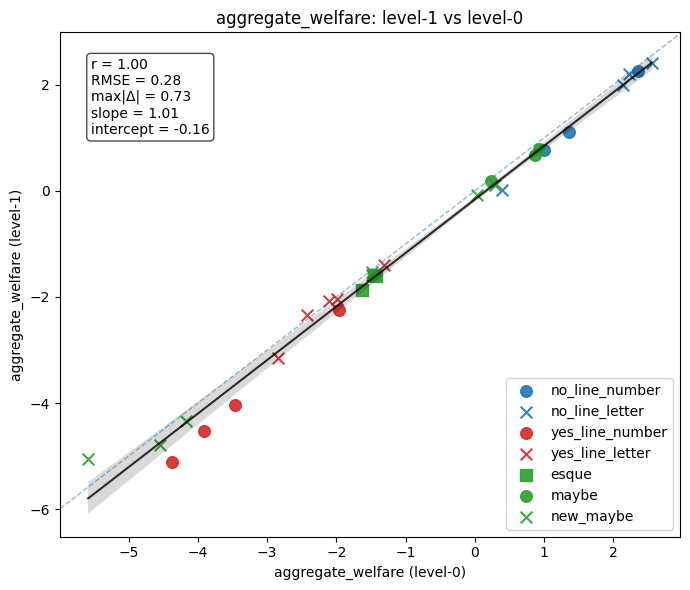

In [6]:
# Global comparison: how well does alt_source track ref_source on this metric?
summary_df, per_map_df = regression_by_source(
    df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source
)

display(summary_df) # summary table
# per_map_df  # uncomment if you want the per-map table

plot_regression_by_source(
    df=df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    #title="Model-predicted universalizability: level-1 vs level-0",
    #xlabel="My level-0 universalizability",
    #ylabel="My level-1 universalizability",
    #save_path="figures/universalizability_1_0.png",
)

,map,delta_aggregate_welfare_level-1_vs_level-0,d_aggregate_welfare_level-1_vs_level-0,q_aggregate_welfare_level-1_vs_level-0,relative_aggregate_welfare_level-1_vs_level-0
113,yes_line_8,-0.727931,-0.318525,-0.089455,0.166351
103,yes_line_10,-0.569091,-0.24902,-0.069935,0.164268
118,yes_line_9,-0.601935,-0.263392,-0.073972,0.153681
108,yes_line_7,-0.290222,-0.126994,-0.035665,0.147804
3,10esque,-0.233506,-0.102177,-0.028695,0.14313
8,7esque,-0.166667,-0.072929,-0.020482,0.11646
149,yes_line_E,-0.307419,-0.134519,-0.037779,0.108431
13,9esque,-0.136667,-0.059802,-0.016795,0.093848
137,yes_line_C,-0.116,-0.050759,-0.014255,0.078449
144,yes_line_D,-0.086364,-0.037791,-0.010613,0.065653


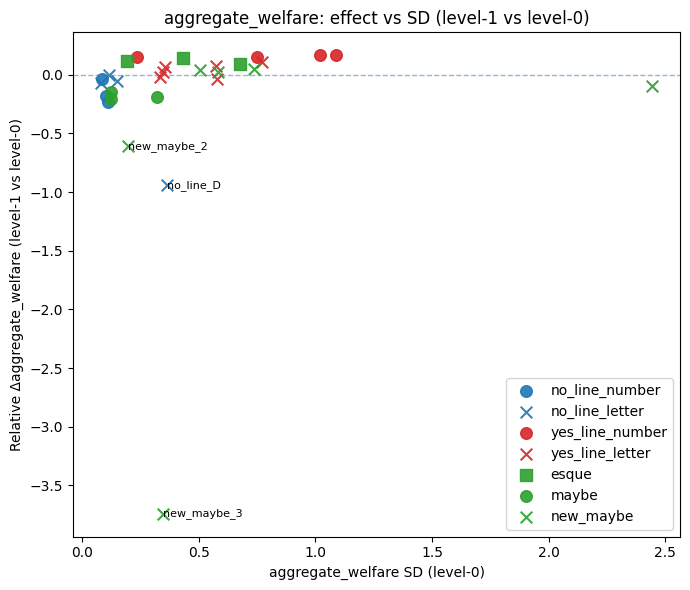

In [8]:
# Map-level effect sizes: where does alt_source differ most from ref_source?

df_eff = add_effect_sizes_by_source(
    df,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source
)

# Effect size columns
delta_col = f"delta_{metric}_{alt_source}_vs_{ref_source}"
d_col     = f"d_{metric}_{alt_source}_vs_{ref_source}"
q_col     = f"q_{metric}_{alt_source}_vs_{ref_source}"
rel_col   = f"relative_{metric}_{alt_source}_vs_{ref_source}"

cols = ["map", delta_col, d_col, q_col, rel_col]

# Sort by relative difference (large negative values at the bottom)
display(
    df_eff[df_eff["source"] == alt_source][cols]
        .sort_values(rel_col, ascending=False)
)

plot_effect_vs_sd_by_source(
    df=df_eff,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    effect_kind="relative",
    #title="Level-1 vs. Level-0: universalizability – relative difference vs map SD",
    #xlabel=f"Noisiness of map (SD of {metric}, {ref_source} runs)",
    #ylabel=f"Relative difference ({alt_source} − {ref_source})/{ref_source}",
    label_threshold=0.25,   # only label reasonably big effects
    #save_path="figures/1_vs_0_relative-diff_vs_sd.png",
)

# Options for effect_kind: "difference", "d", "q", "relative"

,map,delta_aggregate_welfare_level-1_vs_level-0,z_aggregate_welfare_level-1_vs_level-0
57,new_maybe_5,0.522453,1.254972
123,yes_line_A,0.086364,0.791183
154,yes_line_F,0.032941,0.476335
33,new_maybe_1,-0.03907,-0.319244
87,no_line_B,-0.01087,-0.486267
18,maybe_4,-0.043256,-0.717287
130,yes_line_B,-0.050312,-0.740546
137,yes_line_C,-0.116,-0.849604
144,yes_line_D,-0.086364,-1.061656
13,9esque,-0.136667,-1.066288


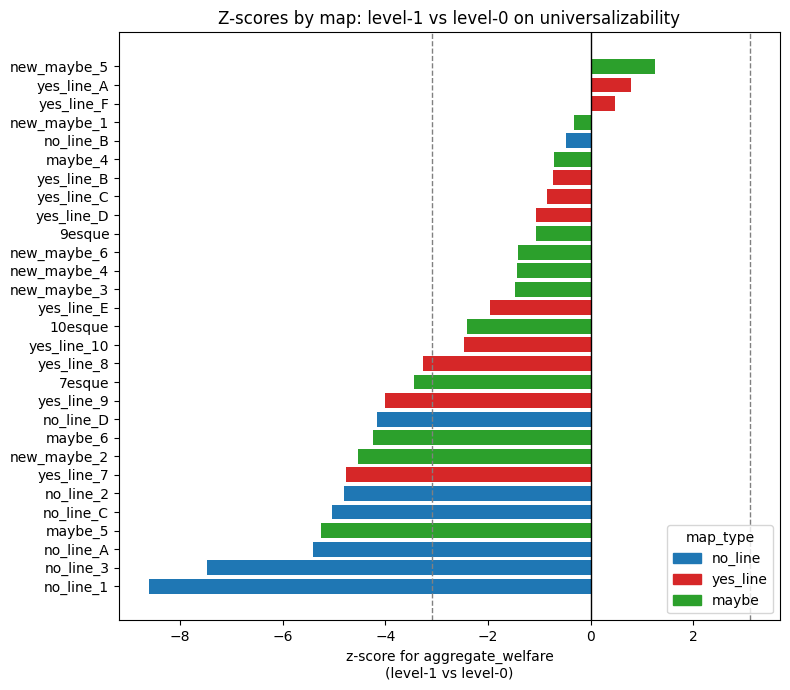

In [10]:
# Z-scores: how large are deviations in SE units?

df_z = add_zscores_by_source(
    df=df_eff,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    se_from="both",   # set to "alt" to treat ref_source as the true distribution
)

# Z-score columns
delta_col = f"delta_{metric}_{alt_source}_vs_{ref_source}"
z_col     = f"z_{metric}_{alt_source}_vs_{ref_source}"

cols = ["map", delta_col, z_col]

# Sort by z-score (large negative values at the bottom)
display(
    df_z[df_z["source"] == alt_source][cols]
        .sort_values(z_col, ascending=False)
)

plot_zscores_by_source(
    df=df_z,
    metric=metric,
    ref_source=ref_source,
    alt_source=alt_source,
    threshold=3.1,    # Bonferroni threshold for 29 maps
    title="Z-scores by map: level-1 vs level-0 on universalizability",
    save_path="figures/zscores_1_vs_0.png",
)
